In [3]:
import pandas as pd
df = pd.read_csv("verbrauch_ausreißen.csv")

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16800 entries, 0 to 16799
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   zaehler_id                        16800 non-null  object 
 1   kunde_id                          16800 non-null  object 
 2   kundentyp                         16800 non-null  object 
 3   vertragsleistung_kw               16800 non-null  int64  
 4   monat                             16800 non-null  object 
 5   monat_idx                         16800 non-null  int64  
 6   arbeitstage                       16800 non-null  int64  
 7   feiertage_im_monat                16800 non-null  int64  
 8   mittlere_temperatur_c             16296 non-null  float64
 9   heiztage                          16800 non-null  int64  
 10  produktionsplan_index             16128 non-null  float64
 11  wartung_aktiv                     16800 non-null  int64  
 12  vorm

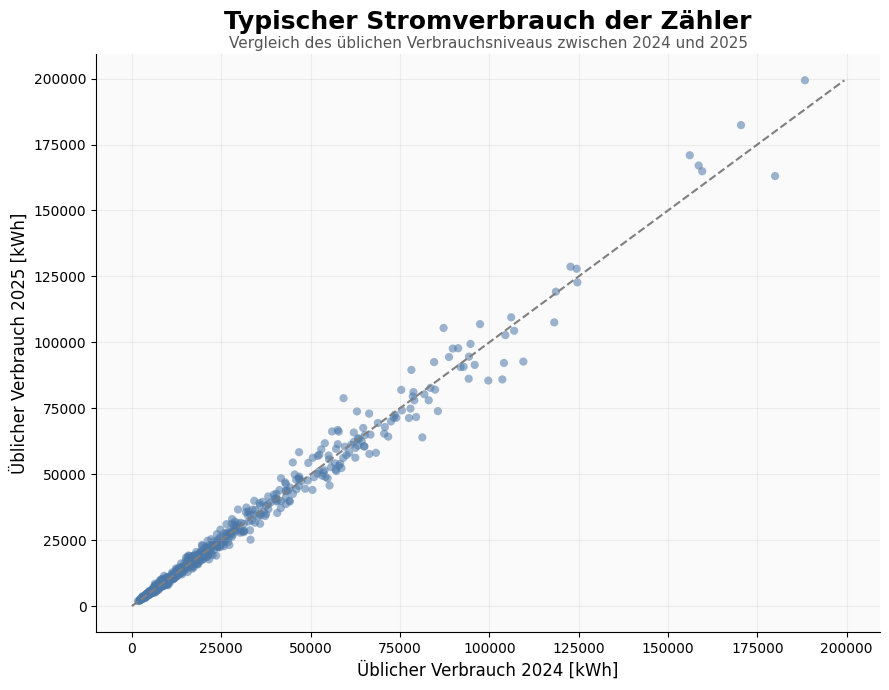

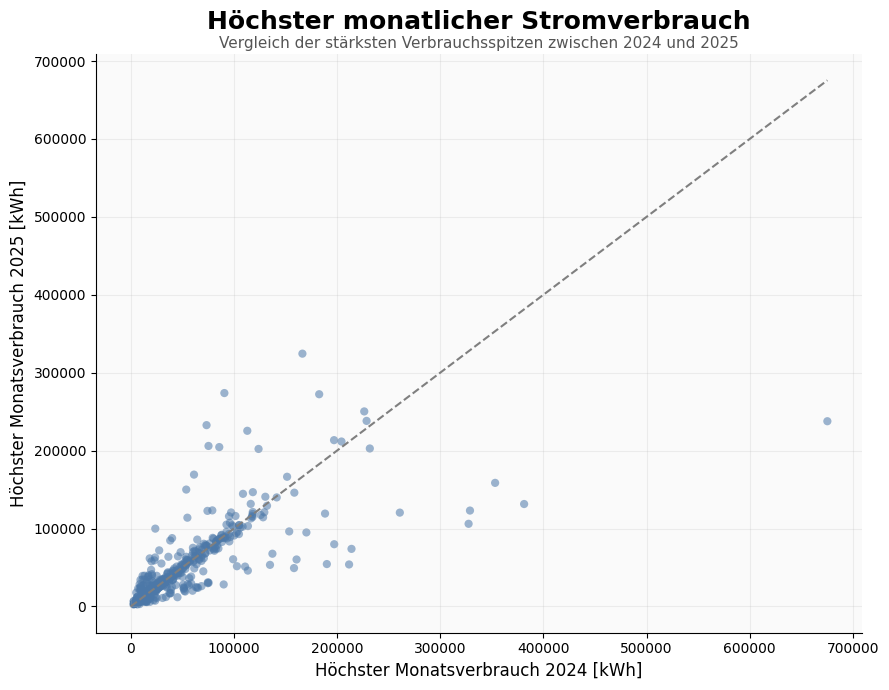

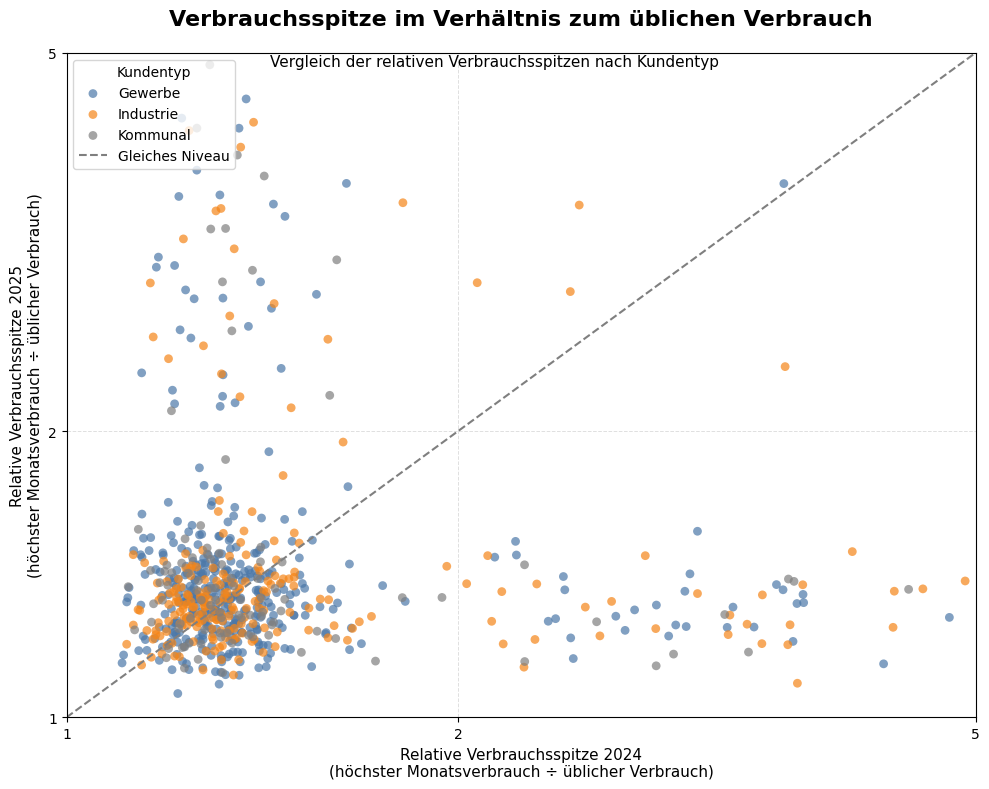

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Daten vorbereiten
# ============================================================

vergleich = (
    df.groupby(["zaehler_id", "jahr"])["verbrauch_kwh"]
      .agg(["median", "max"])
      .unstack()
)

vergleich.columns = [
    f"{metric}_{jahr}"
    for metric, jahr in vergleich.columns
]

vergleich = vergleich.dropna().copy()

# Relative Verbrauchsspitze
vergleich["spitze_2024"] = (
    vergleich["max_2024"] / vergleich["median_2024"]
)

vergleich["spitze_2025"] = (
    vergleich["max_2025"] / vergleich["median_2025"]
)

# ============================================================
# Einheitliches Design
# ============================================================

farbe_punkte = "#4C78A8"
farbe_diagonale = "#7F7F7F"

def basis_plot():
    fig, ax = plt.subplots(figsize=(9, 7))

    ax.set_facecolor("#FAFAFA")

    # Nur linke und untere Achse
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        True,
        alpha=0.20,
        linewidth=0.8
    )

    return fig, ax


# ============================================================
# 1. MEDIAN
# ============================================================

fig, ax = basis_plot()

ax.scatter(
    vergleich["median_2024"],
    vergleich["median_2025"],
    s=35,
    alpha=0.55,
    color=farbe_punkte,
    edgecolors="none"
)

max_wert = max(
    vergleich["median_2024"].max(),
    vergleich["median_2025"].max()
)

ax.plot(
    [0, max_wert],
    [0, max_wert],
    linestyle="--",
    linewidth=1.5,
    color=farbe_diagonale
)

ax.set_title(
    "Typischer Stromverbrauch der Zähler",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Vergleich des üblichen Verbrauchsniveaus zwischen 2024 und 2025",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#555555"
)

ax.set_xlabel(
    "Üblicher Verbrauch 2024 [kWh]",
    fontsize=12
)

ax.set_ylabel(
    "Üblicher Verbrauch 2025 [kWh]",
    fontsize=12
)

ax.ticklabel_format(
    style="plain",
    axis="both"
)

plt.tight_layout()

plt.savefig(
    "01_typischer_verbrauch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. MAX
# ============================================================

fig, ax = basis_plot()

ax.scatter(
    vergleich["max_2024"],
    vergleich["max_2025"],
    s=35,
    alpha=0.55,
    color=farbe_punkte,
    edgecolors="none"
)

max_wert = max(
    vergleich["max_2024"].max(),
    vergleich["max_2025"].max()
)

ax.plot(
    [0, max_wert],
    [0, max_wert],
    linestyle="--",
    linewidth=1.5,
    color=farbe_diagonale
)

ax.set_title(
    "Höchster monatlicher Stromverbrauch",
    fontsize=18,
    fontweight="bold",
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Vergleich der stärksten Verbrauchsspitzen zwischen 2024 und 2025",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#555555"
)

ax.set_xlabel(
    "Höchster Monatsverbrauch 2024 [kWh]",
    fontsize=12
)

ax.set_ylabel(
    "Höchster Monatsverbrauch 2025 [kWh]",
    fontsize=12
)

ax.ticklabel_format(
    style="plain",
    axis="both"
)

plt.tight_layout()

plt.savefig(
    "02_hoechster_verbrauch.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 3. MAX / MEDIAN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter

# ============================================================
# 1. vorbereitung
# ============================================================

vergleich = (
    df.groupby(["zaehler_id", "jahr"])
      .agg(
          median=("verbrauch_kwh", "median"),
          maximum=("verbrauch_kwh", "max"),
          kundentyp=("kundentyp", "first")
      )
      .reset_index()
)

# 2024 / 2025 in separate columns
vergleich_wide = vergleich.pivot(
    index="zaehler_id",
    columns="jahr",
    values=["median", "maximum"]
)

vergleich_wide.columns = [
    f"{wert}_{jahr}"
    for wert, jahr in vergleich_wide.columns
]

vergleich_wide = vergleich_wide.reset_index()

# ============================================================
# 2. Kundentyp pro Zähler ergänzen
# ============================================================

kundentyp_zaehler = (
    df.groupby("zaehler_id")["kundentyp"]
      .first()
)

vergleich_wide["kundentyp"] = (
    vergleich_wide["zaehler_id"]
    .map(kundentyp_zaehler)
)

# ============================================================
# 3. Relative Verbrauchsspitze berechnen
# ============================================================

vergleich_wide["spitze_2024"] = (
    vergleich_wide["maximum_2024"]
    / vergleich_wide["median_2024"]
)

vergleich_wide["spitze_2025"] = (
    vergleich_wide["maximum_2025"]
    / vergleich_wide["median_2025"]
)

# ============================================================
# 4. Nur gültige Werte
# ============================================================

vergleich_wide = vergleich_wide[
    np.isfinite(vergleich_wide["spitze_2024"]) &
    np.isfinite(vergleich_wide["spitze_2025"]) &
    (vergleich_wide["spitze_2024"] >= 1) &
    (vergleich_wide["spitze_2025"] >= 1) &
    vergleich_wide["kundentyp"].notna()
].copy()

# ============================================================
# 5. Werte
# ============================================================

x = vergleich_wide["spitze_2024"]
y = vergleich_wide["spitze_2025"]

# ============================================================
# 6. Achsengrenze bestimmen
# ============================================================

obergrenze = max(
    x.quantile(0.99),
    y.quantile(0.99)
)

obergrenze = obergrenze * 1.15

# mindestens bis 5
obergrenze = max(obergrenze, 5)

# Wenn alle Daten <= 100 sind, nicht unnötig bis 100 gehen
tatsaechliches_maximum = max(x.max(), y.max())

if tatsaechliches_maximum <= 100:
    obergrenze = min(obergrenze, 100)

# ============================================================
# 7. Farben für die drei Kundentypen
# ============================================================

farben = {
    "Gewerbe": "#4C78A8",
    "Industrie": "#F58518",
    "Privat": "#54A24B"
}

# ============================================================
# 8. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Punkte für jeden Kundentyp separat zeichnen
for kundentyp, gruppe in vergleich_wide.groupby("kundentyp"):

    ax.scatter(
        gruppe["spitze_2024"],
        gruppe["spitze_2025"],
        s=40,
        alpha=0.70,
        color=farben.get(kundentyp, "#7F7F7F"),
        label=kundentyp,
        edgecolors="none"
    )

# ============================================================
# 9. Diagonale: 2025 = 2024
# ============================================================

ax.plot(
    [1, obergrenze],
    [1, obergrenze],
    linestyle="--",
    linewidth=1.5,
    color="#7F7F7F",
    label="Gleiches Niveau"
)

# ============================================================
# 10. Logarithmische Achsen
# ============================================================

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlim(1, obergrenze)
ax.set_ylim(1, obergrenze)

# ============================================================
# 11. Nur gewünschte Tick-Werte
# ============================================================

alle_ticks = [1, 2, 5, 10, 20, 50, 100]

sichtbare_ticks = [
    tick for tick in alle_ticks
    if tick <= obergrenze
]

tick_labels = [
    str(tick) for tick in sichtbare_ticks
]

# X-Achse
ax.xaxis.set_major_locator(
    FixedLocator(sichtbare_ticks)
)

ax.xaxis.set_major_formatter(
    FixedFormatter(tick_labels)
)

# Y-Achse
ax.yaxis.set_major_locator(
    FixedLocator(sichtbare_ticks)
)

ax.yaxis.set_major_formatter(
    FixedFormatter(tick_labels)
)

# ============================================================
# 12. Alle Minor-Ticks entfernen
# ============================================================

ax.xaxis.set_minor_locator(FixedLocator([]))
ax.yaxis.set_minor_locator(FixedLocator([]))

ax.xaxis.set_minor_formatter(FixedFormatter([]))
ax.yaxis.set_minor_formatter(FixedFormatter([]))

# ============================================================
# 13. Beschriftungen
# ============================================================

ax.set_xlabel(
    "Relative Verbrauchsspitze 2024\n"
    "(höchster Monatsverbrauch ÷ üblicher Verbrauch)",
    fontsize=11
)

ax.set_ylabel(
    "Relative Verbrauchsspitze 2025\n"
    "(höchster Monatsverbrauch ÷ üblicher Verbrauch)",
    fontsize=11
)

ax.set_title(
    "Verbrauchsspitze im Verhältnis zum üblichen Verbrauch",
    fontsize=16,
    fontweight="bold",
    pad=20
)

fig.text(
    0.5,
    0.91,
    "Vergleich der relativen Verbrauchsspitzen nach Kundentyp",
    ha="center",
    fontsize=11
)

# ============================================================
# 14. Grid
# ============================================================

ax.grid(
    which="major",
    linestyle="--",
    linewidth=0.7,
    alpha=0.4
)

ax.grid(
    which="minor",
    visible=False
)

# ============================================================
# 15. Legende
# ============================================================

ax.legend(
    title="Kundentyp",
    loc="upper left",
    frameon=True
)

# ============================================================
# 16. Layout
# ============================================================

plt.tight_layout()

# ============================================================
# 17. Speichern
# ============================================================

plt.savefig(
    "03_relative_verbrauchsspitze_kundentyp.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()